In [541]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score

## Data Overview

In [497]:
data = pd.read_csv("garments_worker_productivity.csv", parse_dates=["date"])
data.sample(5)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
951,2015-02-26,Quarter4,sweing,Thursday,9,0.75,18.79,1020.0,5640,45,0.0,0,1,52.0,0.750372
297,2015-01-17,Quarter3,sweing,Saturday,5,0.70,41.19,1052.0,10440,21,0.0,0,0,58.0,0.452013
311,2015-01-18,Quarter3,sweing,Sunday,11,0.65,14.89,1140.0,10260,44,0.0,0,0,57.0,0.650300
253,2015-01-14,Quarter2,sweing,Wednesday,4,0.60,22.40,816.0,5100,23,0.0,0,0,57.0,0.600370
801,2015-02-16,Quarter3,sweing,Monday,9,0.60,18.79,2103.0,5400,0,0.0,0,1,54.0,0.329965


In [498]:
# Shape
data.shape

(1197, 15)

In [499]:
# Check for missing values
data.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [500]:
# Summary stats
data.describe()

,date,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,2015-02-04 10:56:50.526315776,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
min,2015-01-01 00:00:00,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,2015-01-18 00:00:00,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,2015-02-03 00:00:00,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,2015-02-23 00:00:00,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,2015-03-11 00:00:00,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437
std,NaN,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488


In [501]:
# Data types of the columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1197 non-null   datetime64[ns]
 1   quarter                1197 non-null   object        
 2   department             1197 non-null   object        
 3   day                    1197 non-null   object        
 4   team                   1197 non-null   int64         
 5   targeted_productivity  1197 non-null   float64       
 6   smv                    1197 non-null   float64       
 7   wip                    691 non-null    float64       
 8   over_time              1197 non-null   int64         
 9   incentive              1197 non-null   int64         
 10  idle_time              1197 non-null   float64       
 11  idle_men               1197 non-null   int64         
 12  no_of_style_change     1197 non-null   int64         
 13  no_

### Checking for Categorical values consistency and typos

In [502]:
# Quarter - Move the values of quarter 5 into quarter 4
data["quarter"].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64

In [503]:
data.replace("Quarter5", "Quarter4", inplace=True)

In [504]:
data["quarter"].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    292
Quarter3    210
Name: count, dtype: int64

In [505]:
# Department  -> "sweing" --> "sewing", "finishing " --> "finishing"
data["department"].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

In [506]:
# Day
data["day"].unique()

array(['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype=object)

In [507]:
# team
data["team"].value_counts().sort_index()

team
1     105
2     109
3      95
4     105
5      93
6      94
7      96
8     109
9     104
10    100
11     88
12     99
Name: count, dtype: int64

In [508]:
# Correcting the department values
data.replace({"sweing": "sewing", "finishing ": "finishing"}, inplace=True)

In [509]:
data["department"].unique()

array(['sewing', 'finishing'], dtype=object)

### Drop columns

In [510]:
# Drop wip column
data = data.drop(columns=["wip"])

In [511]:
# Drop date column
data = data.drop(columns=["date"])

In [512]:
# Dropping idle_team, idle_men
data = data.drop(columns=["idle_men", "idle_time"])

In [513]:
data.shape

(1197, 11)

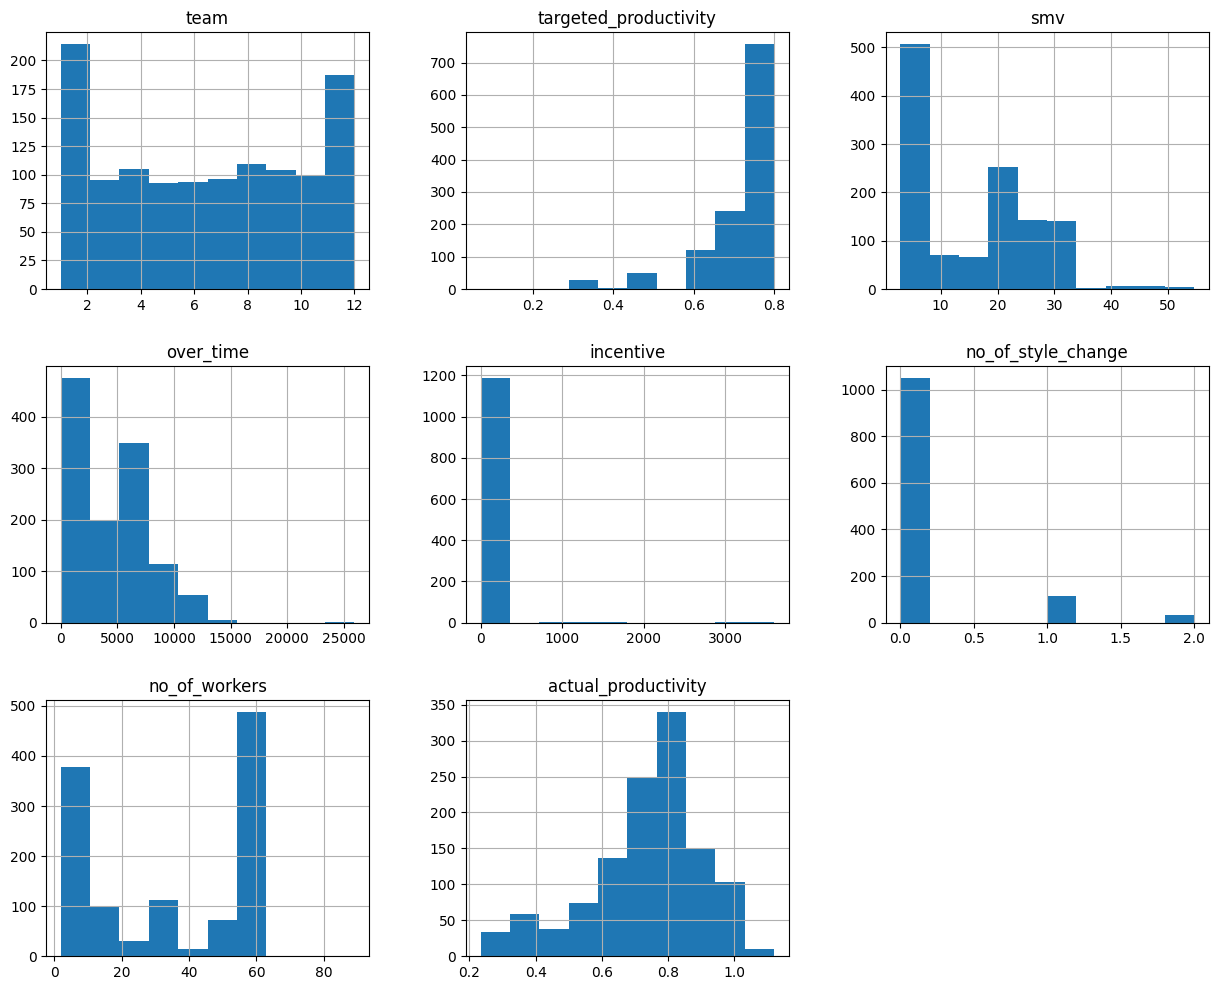

In [514]:
data.hist(figsize=(15, 12))
plt.show()

## Data Cleaning

In [515]:
# Making Quarter Numeric
data["quarter"].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    292
Quarter3    210
Name: count, dtype: int64

In [516]:
data.replace({"Quarter1": 1, "Quarter2": 2, "Quarter3": 3, "Quarter4": 4}, inplace=True)

C:\Users\muham\AppData\Local\Temp\ipykernel_37156\331526543.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Quarter1": 1, "Quarter2": 2, "Quarter3": 3, "Quarter4": 4}, inplace=True)


In [517]:
data.sample(3)

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity
261,3,finishing,Thursday,1,0.80,3.94,1440,0,0,8.0,0.884261
286,3,sewing,Saturday,8,0.80,25.90,10170,50,0,56.5,0.800129
1008,1,sewing,Monday,1,0.65,26.66,6840,65,0,57.0,0.800580


In [518]:
# Making no_of_worker integer
data["no_of_workers"] = data["no_of_workers"].astype("int")

In [519]:
# Actual productivity should feature values to two decimal places
data["actual_productivity"] = data["actual_productivity"].round(2)

In [520]:
data.head()

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity
0,1,sewing,Thursday,8,0.80,26.16,7080,98,0,59,0.94
1,1,finishing,Thursday,1,0.75,3.94,960,0,0,8,0.89
2,1,sewing,Thursday,11,0.80,11.41,3660,50,0,30,0.80
3,1,sewing,Thursday,12,0.80,11.41,3660,50,0,30,0.80
4,1,sewing,Thursday,6,0.80,25.90,1920,50,0,56,0.80


In [521]:
# Setting new column for classifier based on whether productivity was reached or not
data["productive"] = (data["actual_productivity"] >= data["targeted_productivity"])

In [522]:
data.sample(2)

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive
531,4,finishing,Saturday,6,0.6,3.94,1200,0,0,10,0.97,True
717,2,finishing,Wednesday,5,0.7,4.15,240,0,0,2,0.87,True


## Machine learning Data Prep

In [523]:
# Convert department column to boolean
# Change the name of the column to is_sewing
data.rename(columns={"department": "is_sewing"}, inplace=True)
# If the value is sewing, set it to 1, otherwise 0
data["is_sewing"] = data["is_sewing"].map({"sewing": 1, "finishing": 0}).astype("int64")

In [524]:
data.sample(3)

,quarter,is_sewing,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive
1156,2,1,Tuesday,4,0.75,26.82,5880,65,0,59,0.85,True
128,2,1,Thursday,9,0.80,26.16,10620,88,0,59,0.90,True
642,1,0,Saturday,1,0.80,3.94,1200,0,0,10,0.87,True


In [525]:
# Converting the quarter column into dummy variables
data = pd.get_dummies(data, columns=["quarter"], prefix="q")
data.sample(4)

,is_sewing,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4
1170,0,Tuesday,8,0.65,3.90,960,0,0,8,0.56,False,False,True,False,False
1173,0,Wednesday,12,0.80,4.60,2160,0,0,9,0.92,True,False,True,False,False
407,1,Saturday,11,0.75,42.97,10260,56,0,57,0.75,True,False,False,False,True
972,1,Saturday,8,0.75,29.40,4560,56,2,58,0.75,True,False,False,False,True


In [526]:
# Converting day variable into get_dummies
data = pd.get_dummies(data, columns=["day"], prefix="is")

In [527]:
data.sample(4)

,is_sewing,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4,is_Monday,is_Saturday,is_Sunday,is_Thursday,is_Tuesday,is_Wednesday
417,0,2,0.75,3.94,1440,0,0,8,0.97,True,False,False,False,True,False,False,True,False,False,False
229,1,2,0.80,28.08,10530,50,0,58,0.80,True,False,True,False,False,False,False,False,False,True,False
683,1,4,0.70,30.10,3300,50,1,57,0.79,True,False,True,False,False,True,False,False,False,False,False
1089,1,1,0.70,26.82,8160,70,0,58,0.85,True,True,False,False,False,False,True,False,False,False,False


In [528]:
# Converting the team into get_dummies
data = pd.get_dummies(data, columns=["team"], prefix="team")

In [529]:
data.sample(4)

,is_sewing,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive,q_1,...,team_3,team_4,team_5,team_6,team_7,team_8,team_9,team_10,team_11,team_12
918,0,0.70,2.90,960,0,0,8,0.50,False,False,...,False,False,False,False,False,False,False,False,True,False
331,1,0.65,20.40,8280,35,0,58,0.65,True,False,...,False,False,True,False,False,False,False,False,False,False
406,1,0.75,15.26,6120,40,0,34,0.75,True,False,...,False,False,False,False,False,False,False,False,False,True
318,0,0.70,4.30,5040,0,0,28,0.98,True,False,...,False,True,False,False,False,False,False,False,False,False


## Build the Decision Tree

In [530]:
# Separate the Data
X = data.drop(columns=["actual_productivity", "productive"], axis=1)
y = data["productive"]

In [531]:
X.shape

(1197, 29)

In [532]:
y.shape

(1197,)

In [533]:
# Split the data into train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=0)

In [534]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(897, 29) (300, 29)
(897,) (300,)


In [535]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [536]:
y_predict = tree.predict(X_test)

## Visualizing the model

In [537]:
print(f"Accuracy: {accuracy_score(y_test, y_predict)}")

Accuracy: 0.78


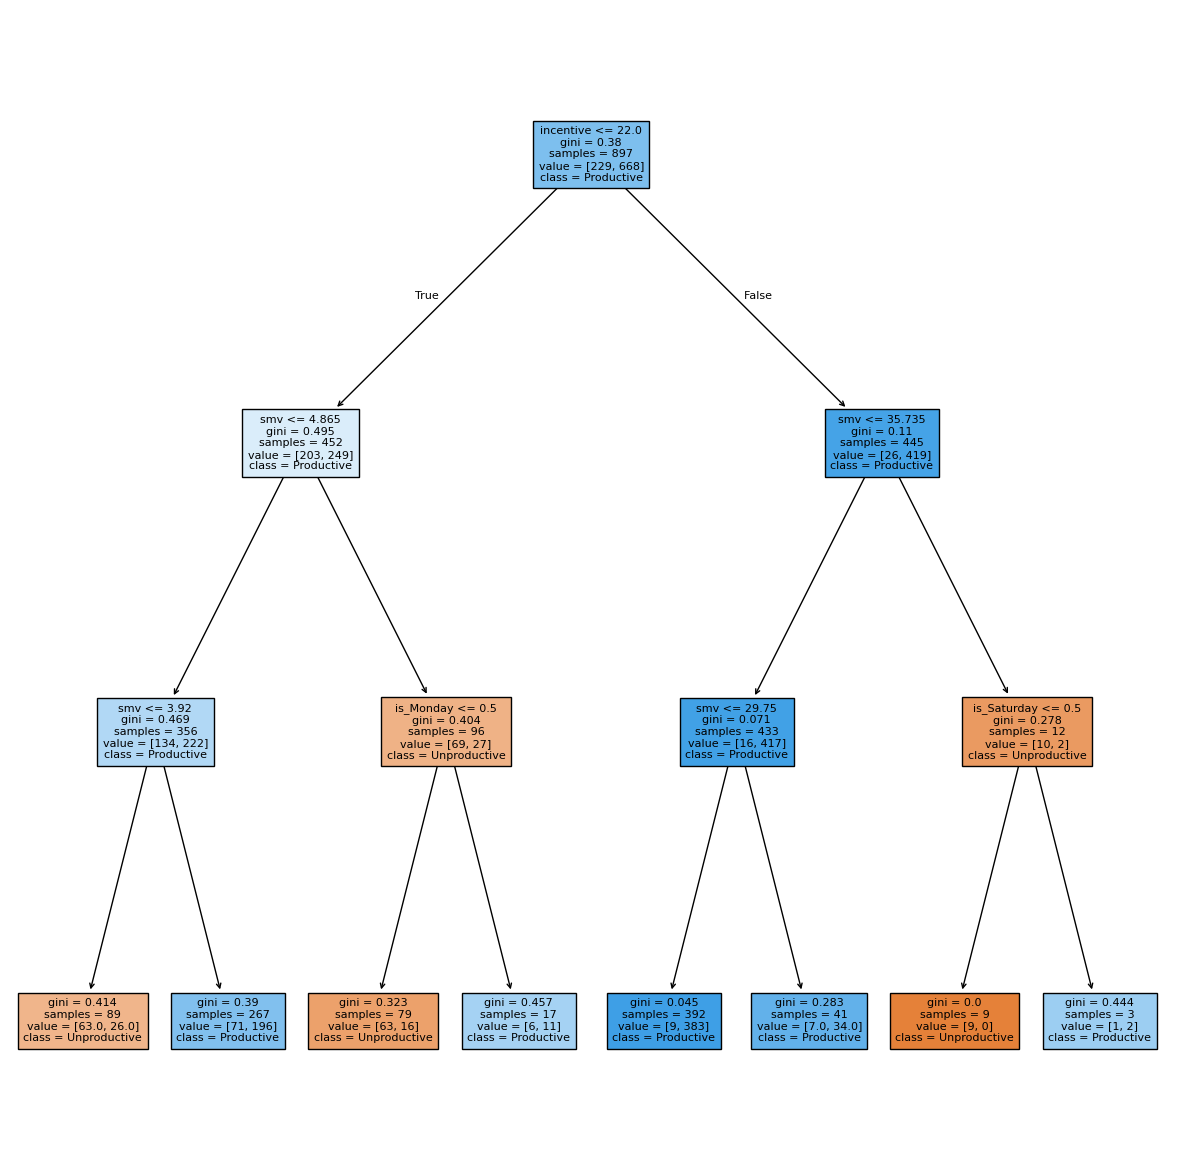

In [538]:
plt.figure(figsize=(15, 15))
plot_tree(tree, feature_names=X.columns, class_names=["Unproductive", "Productive"], filled=True, fontsize=8)
plt.show()

## Evaluating the Model

In [539]:
confusion_matrix(y_test, y_predict)

array([[ 38,  35],
       [ 31, 196]])

In [540]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_predict), 2))
print("Recall:", round(recall_score(y_test, y_predict), 2))
print("F1 Score:", round(f1_score(y_test, y_predict), 2))
print("----")
print("Accuracy:", round(tree.score(X_test, y_test), 2))

Precision: 0.85
Recall: 0.86
F1 Score: 0.86
----
Accuracy: 0.78


In [542]:
scores = cross_val_score(tree, X, y, cv=8)

In [543]:
print(scores)

[0.86       0.68666667 0.84       0.86666667 0.82666667 0.74496644
 0.83221477 0.7852349 ]


In [545]:
print(f"Cross Validation Accuracy Scores: {scores}")
print(f"Average Cross validation Score: {round(scores.mean(), 2)}")

Cross Validation Accuracy Scores: [0.86       0.68666667 0.84       0.86666667 0.82666667 0.74496644
 0.83221477 0.7852349 ]
Average Cross validation Score: 0.81


In [546]:
from sklearn.model_selection import cross_validate

multiple_cross_scores = cross_validate(
                             tree,
                             X, y, cv=10,
                             scoring= ("precision", "recall", "f1") )

print("Mean Cross Validated Precision:", round(multiple_cross_scores["test_precision"].mean(), 2))
print("Mean Cross Validated recall:", round(multiple_cross_scores["test_recall"].mean(), 2))
print("Mean Cross Validated F1:", round(multiple_cross_scores["test_f1"].mean(), 2))

Mean Cross Validated Precision: 0.85
Mean Cross Validated recall: 0.92
Mean Cross Validated F1: 0.88
